In [ ]:
import pandas as pd
from google.colab import drive
from sklearn.model_selection import train_test_split

drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/datasets/diabetes_binary_health_indicators_BRFSS2015.csv'

df = pd.read_csv(file_path)
x= df.drop('Diabetes_binary', axis=1)
y=df['Diabetes_binary']

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, stratify = y, random_state=42)

print("train : ", xtrain.shape)
print("test : ", xtest.shape)

print("train ratio : ")
print(ytrain.value_counts(normalize=True))
print("test ratio : ")
print(ytest.value_counts(normalize=True))

Mounted at /content/drive
train :  (202944, 21)
test :  (50736, 21)
train ratio : 
Diabetes_binary
0.0    0.860666
1.0    0.139334
Name: proportion, dtype: float64
test ratio : 
Diabetes_binary
0.0    0.860671
1.0    0.139329
Name: proportion, dtype: float64


In [ ]:
trainbaldf= pd.DataFrame(xtrain, columns = x.columns)
trainbaldf['Diabetes_binary']= ytrain

testrealdf = pd.DataFrame(xtest, columns = x.columns)
testrealdf['Diabetes_binary']= ytest

trainbaldf.to_csv('/content/drive/MyDrive/datasets/trainbaldf.csv', index=False)
testrealdf.to_csv('/content/drive/MyDrive/datasets/testrealdf.csv', index=False)

files.downlaod('trainbaldf')

NameError: name 'files' is not defined

In [ ]:
from google.colab import files

trainbaldf11= pd.DataFrame(xtrain, columns = x.columns)
trainbaldf11['Diabetes_binary']= ytrain

testrealdf11 = pd.DataFrame(xtest, columns = x.columns)
testrealdf11['Diabetes_binary']= ytest

trainbaldf11.to_csv('trainbaldf11.csv', index=False)
testrealdf11.to_csv('testrealdf11.csv', index=False)

files.download('trainbaldf11.csv')
files.download('testrealdf11.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

#data split --> feature selection --> correlation matrix generation --> heatmap --> dimention reduction
#---> undersampling
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler


drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/datasets/trainbaldf11.csv'


df = pd.read_csv(file_path)
x = df.drop('Diabetes_binary', axis=1) ## that ground truth we predict ---> 'Diabetes_binary'
use = df['Diabetes_binary']

pdx = pd.DataFrame(x)
pduse = pd.Series(use)


print(list(df.columns))
df.head(20)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income', 'Diabetes_binary']


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,0.0,0.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,1.0,...,0.0,2.0,0.0,0.0,0.0,1.0,2.0,4.0,5.0,0.0
1,1.0,0.0,1.0,23.0,1.0,0.0,0.0,1.0,1.0,1.0,...,0.0,2.0,0.0,0.0,0.0,1.0,13.0,4.0,7.0,0.0
2,1.0,1.0,1.0,29.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,9.0,6.0,8.0,0.0
3,1.0,1.0,1.0,39.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,0.0,0.0,0.0,1.0,7.0,4.0,7.0,0.0
4,0.0,1.0,1.0,16.0,1.0,0.0,0.0,1.0,1.0,1.0,...,1.0,5.0,30.0,30.0,1.0,0.0,7.0,5.0,1.0,0.0
5,1.0,0.0,1.0,32.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,2.0,0.0,0.0,0.0,1.0,7.0,6.0,8.0,0.0
6,1.0,0.0,1.0,37.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,4.0,0.0,0.0,0.0,0.0,4.0,5.0,4.0,1.0
7,0.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,2.0,3.0,1.0,0.0,1.0,5.0,5.0,6.0,0.0
8,0.0,0.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,3.0,10.0,15.0,1.0,0.0,5.0,6.0,8.0,0.0
9,0.0,0.0,1.0,23.0,1.0,0.0,0.0,1.0,1.0,1.0,...,0.0,2.0,0.0,3.0,0.0,0.0,6.0,6.0,8.0,0.0


In [ ]:
use.head(10)

In [ ]:
print(df.isnull().sum())

HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
Diabetes_binary         0
dtype: int64


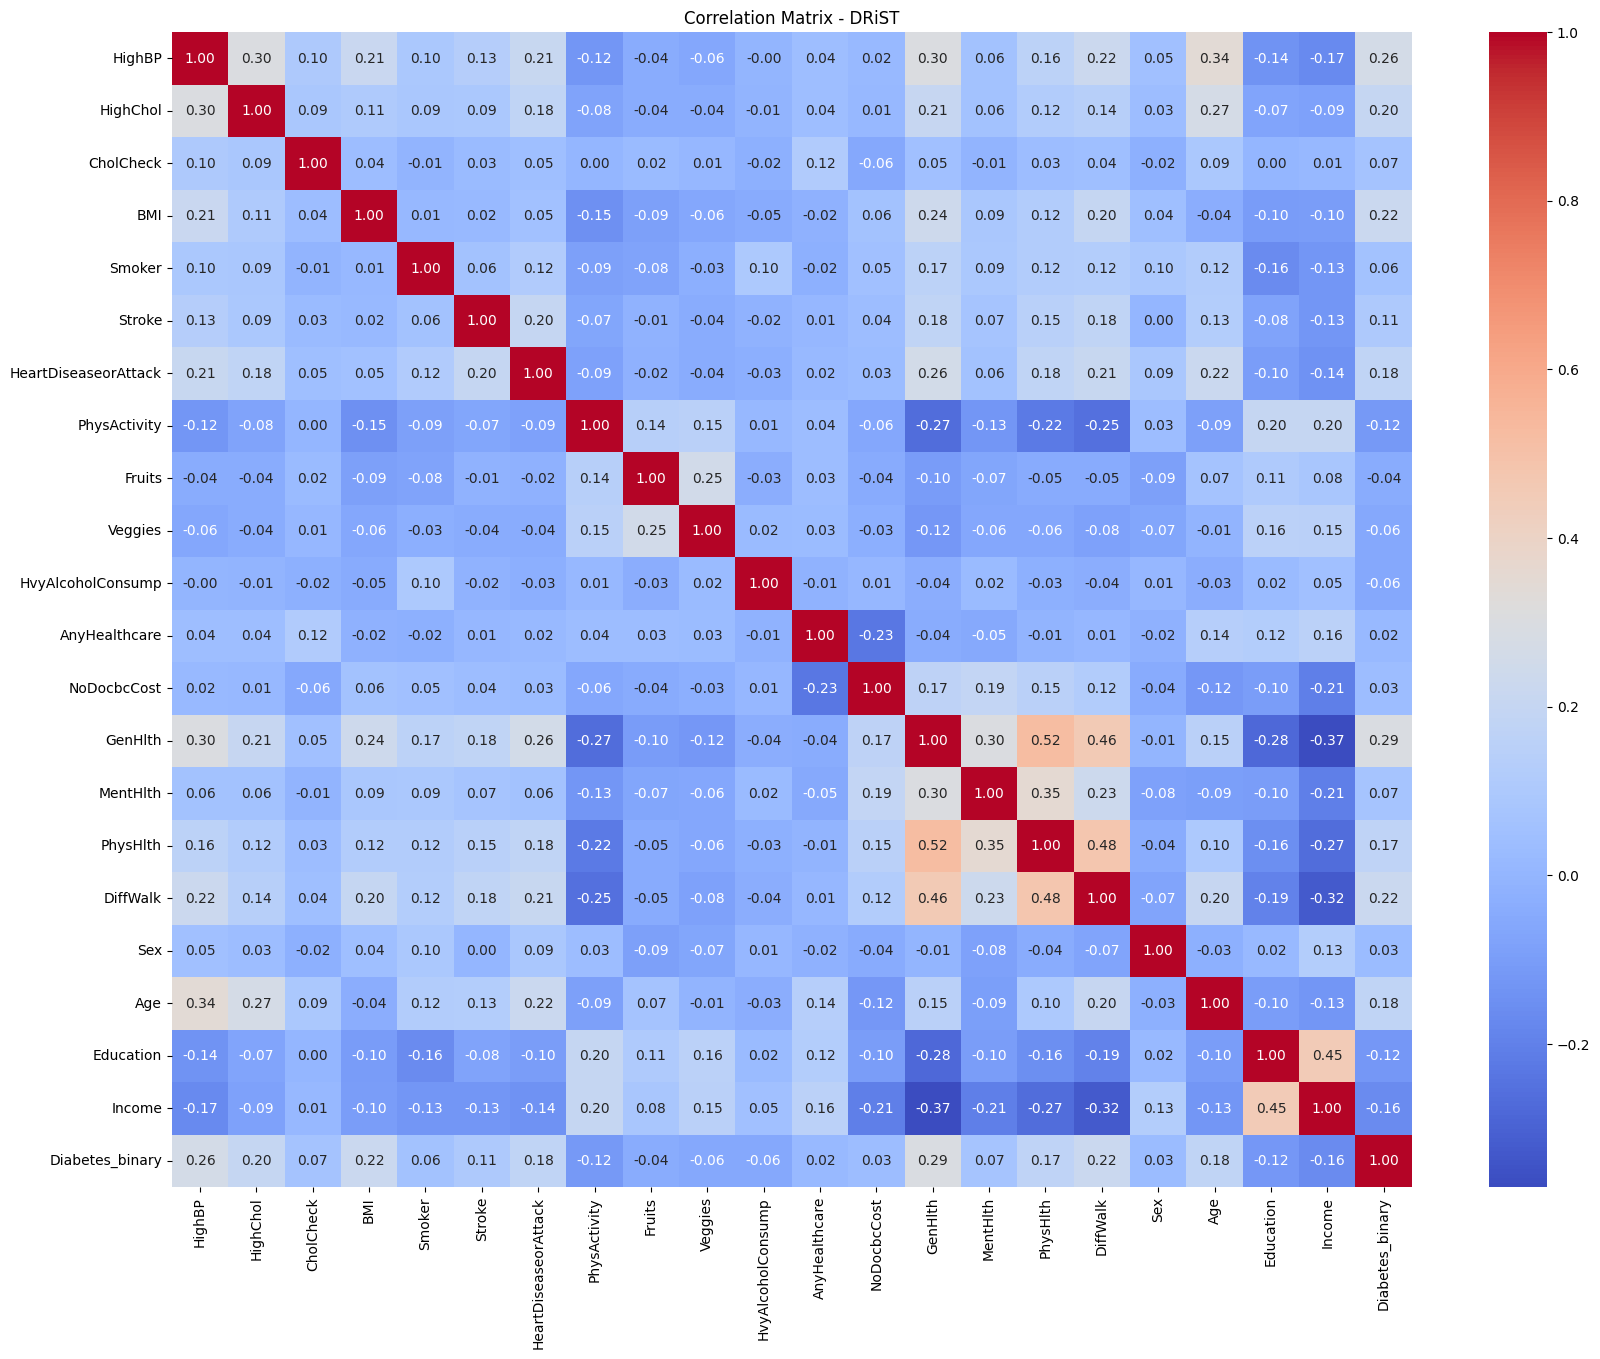

In [ ]:
#corralation matrix - b4
import seaborn as sns
corr_matrix = df.corr()
corr_matrix

plt.figure(figsize=(20,15))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix - DRiST")
plt.show()

In [ ]:

df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202944 entries, 0 to 202943
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HighBP                202944 non-null  float64
 1   HighChol              202944 non-null  float64
 2   CholCheck             202944 non-null  float64
 3   BMI                   202944 non-null  float64
 4   Smoker                202944 non-null  float64
 5   Stroke                202944 non-null  float64
 6   HeartDiseaseorAttack  202944 non-null  float64
 7   PhysActivity          202944 non-null  float64
 8   Fruits                202944 non-null  float64
 9   Veggies               202944 non-null  float64
 10  HvyAlcoholConsump     202944 non-null  float64
 11  AnyHealthcare         202944 non-null  float64
 12  NoDocbcCost           202944 non-null  float64
 13  GenHlth               202944 non-null  float64
 14  MentHlth              202944 non-null  float64
 15  

,0
HighBP,float64
HighChol,float64
CholCheck,float64
BMI,float64
Smoker,float64
Stroke,float64
HeartDiseaseorAttack,float64
PhysActivity,float64
Fruits,float64
Veggies,float64


In [ ]:
from sklearn.feature_selection import SelectKBest, chi2

categorical_features = [
    'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack',
    'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare',
    'NoDocbcCost', 'DiffWalk', 'Sex', 'Education', 'Income'
]

# Make sure all selected categorical features exist in pdx
# Also ensure the target pduse is suitable for chi2 (integer/binary)

# Filter pdx to only include the identified categorical features
pdx_categorical = pdx[categorical_features].copy()

# Convert columns to appropriate type if necessary (e.g., int for chi2)
# Chi2 works best with non-negative integers. Our current float64 (0.0, 1.0, etc.) will work.
# Ensure target is also int/binary for chi2
pduse_chi2 = pduse.astype(int)

# Apply SelectKBest with chi2
# We'll select all categorical features to get their scores and p-values
selector_chi2 = SelectKBest(chi2, k='all')
selector_chi2.fit(pdx_categorical, pduse_chi2)

# Get the scores and p-values
chi2_scores = pd.DataFrame({
    'Feature': pdx_categorical.columns,
    'Chi2_Score': selector_chi2.scores_,
    'P_Value': selector_chi2.pvalues_
})

# Sort by Chi2 score in descending order to see the most important features first
chi2_scores = chi2_scores.sort_values(by='Chi2_Score', ascending=False)

print("Chi-Square Scores for Categorical Features (ranked by importance):\n")
display(chi2_scores)

print("\n--- Interpretation ---\n")
print("Higher Chi2_Score indicates a stronger statistical dependence between the feature and the target variable.")
print("Lower P_Value (typically < 0.05) suggests that the relationship is statistically significant.")
print("Features with high Chi2_Score and low P_Value are strong candidates for retention.")

Chi-Square Scores for Categorical Features (ranked by importance):



,Feature,Chi2_Score,P_Value
12,DiffWalk,8157.506985,0.000000e+00
0,HighBP,8040.608162,0.000000e+00
5,HeartDiseaseorAttack,5824.065965,0.000000e+00
1,HighChol,4707.204305,0.000000e+00
15,Income,3884.252532,0.000000e+00
4,Stroke,2201.871650,0.000000e+00
6,PhysActivity,685.786863,3.685439e-151
9,HvyAlcoholConsump,622.517394,2.119507e-137
14,Education,598.118047,4.296747e-132
3,Smoker,425.786089,1.342937e-94



--- Interpretation ---

Higher Chi2_Score indicates a stronger statistical dependence between the feature and the target variable.
Lower P_Value (typically < 0.05) suggests that the relationship is statistically significant.
Features with high Chi2_Score and low P_Value are strong candidates for retention.


Now, let's calculate the **inter-feature correlation matrix** for the current set of features in `pdx`. This helps us identify potential multicollinearity, where features are highly correlated with each other.

Inter-feature Correlation Matrix (first 5 rows/cols):


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
HighBP,1.000000,0.299342,0.101135,0.213497,0.095577,0.129802,0.209412,-0.124262,-0.041044,-0.061118,...,0.038153,0.017150,0.300355,0.058238,0.162354,0.224658,0.051603,0.343380,-0.139283,-0.170870
HighChol,0.299342,1.000000,0.087240,0.106918,0.088980,0.091933,0.180557,-0.077769,-0.041620,-0.040700,...,0.041097,0.012036,0.207715,0.062679,0.120601,0.143727,0.032235,0.270352,-0.070925,-0.085290
CholCheck,0.101135,0.087240,1.000000,0.036097,-0.009822,0.025286,0.045210,0.003357,0.023067,0.006010,...,0.115559,-0.058421,0.049151,-0.006219,0.033461,0.042365,-0.023033,0.091578,0.001360,0.013234
BMI,0.213497,0.106918,0.036097,1.000000,0.013366,0.019424,0.054109,-0.147375,-0.087687,-0.062480,...,-0.017457,0.058270,0.239398,0.086632,0.120696,0.198267,0.042591,-0.036187,-0.103689,-0.100545
Smoker,0.095577,0.088980,-0.009822,0.013366,1.000000,0.063454,0.115281,-0.087621,-0.077608,-0.032072,...,-0.023722,0.048448,0.165137,0.091685,0.118589,0.122736,0.095371,0.119716,-0.163083,-0.125015


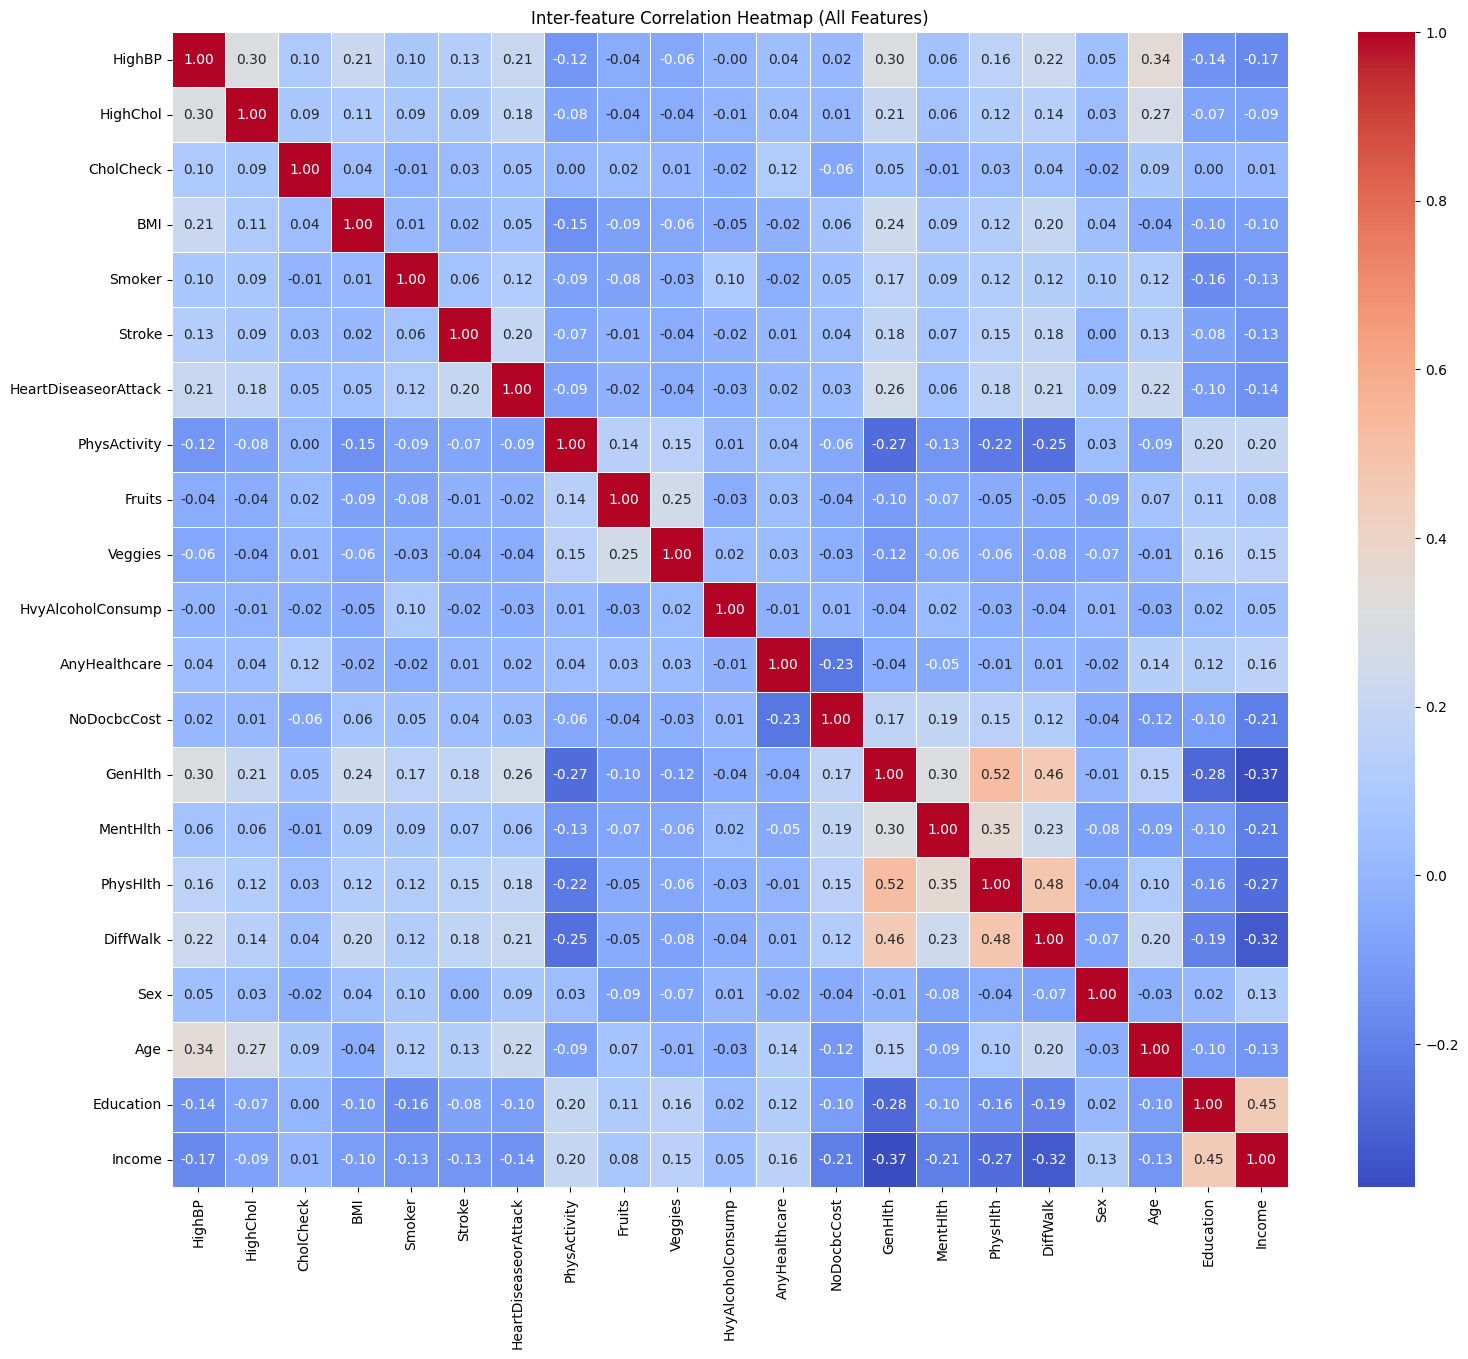

In [ ]:
# Calculate the correlation matrix for the features in pdx
inter_feature_corr = pdx.corr()

print("Inter-feature Correlation Matrix (first 5 rows/cols):")
display(inter_feature_corr.head())

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(18, 15))
sns.heatmap(inter_feature_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Inter-feature Correlation Heatmap (All Features)')
plt.show()

In [ ]:
# gonna drop data - byeee
#pdx2 = df.drop('NoDocbcCost', axis=1)
#pdx2 = df.drop('Fruits', axis=1)
#pdx2 = df.drop('Veggies', axis=1)
#pdx2 = df.drop('Sex', axis=1)
#pdx2 = df.drop('AnyHealthcare', axis=1)
#pdx2 = df.drop('CholCheck', axis=1)
#pdx2.head(10)

,HighBP,HighChol,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,0.0,0.0,28.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,...,0.0,2.0,0.0,0.0,0.0,1.0,2.0,4.0,5.0,0.0
1,1.0,0.0,23.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,...,0.0,2.0,0.0,0.0,0.0,1.0,13.0,4.0,7.0,0.0
2,1.0,1.0,29.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,9.0,6.0,8.0,0.0
3,1.0,1.0,39.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,0.0,0.0,0.0,1.0,7.0,4.0,7.0,0.0
4,0.0,1.0,16.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,...,1.0,5.0,30.0,30.0,1.0,0.0,7.0,5.0,1.0,0.0
5,1.0,0.0,32.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,2.0,0.0,0.0,0.0,1.0,7.0,6.0,8.0,0.0
6,1.0,0.0,37.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,4.0,0.0,0.0,0.0,0.0,4.0,5.0,4.0,1.0
7,0.0,0.0,27.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,2.0,3.0,1.0,0.0,1.0,5.0,5.0,6.0,0.0
8,0.0,0.0,24.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,3.0,10.0,15.0,1.0,0.0,5.0,6.0,8.0,0.0
9,0.0,0.0,23.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,...,0.0,2.0,0.0,3.0,0.0,0.0,6.0,6.0,8.0,0.0


Corrected Inter-feature Correlation Matrix (first 5 rows/cols after dropping features):


,HighBP,HighChol,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Age,Education,Income
HighBP,1.000000,0.299342,0.213497,0.095577,0.129802,0.209412,-0.124262,-0.002297,0.300355,0.058238,0.162354,0.224658,0.343380,-0.139283,-0.170870
HighChol,0.299342,1.000000,0.106918,0.088980,0.091933,0.180557,-0.077769,-0.011077,0.207715,0.062679,0.120601,0.143727,0.270352,-0.070925,-0.085290
BMI,0.213497,0.106918,1.000000,0.013366,0.019424,0.054109,-0.147375,-0.046493,0.239398,0.086632,0.120696,0.198267,-0.036187,-0.103689,-0.100545
Smoker,0.095577,0.088980,0.013366,1.000000,0.063454,0.115281,-0.087621,0.100551,0.165137,0.091685,0.118589,0.122736,0.119716,-0.163083,-0.125015
Stroke,0.129802,0.091933,0.019424,0.063454,1.000000,0.202060,-0.069625,-0.015707,0.176395,0.070194,0.146849,0.176243,0.126482,-0.075941,-0.128436


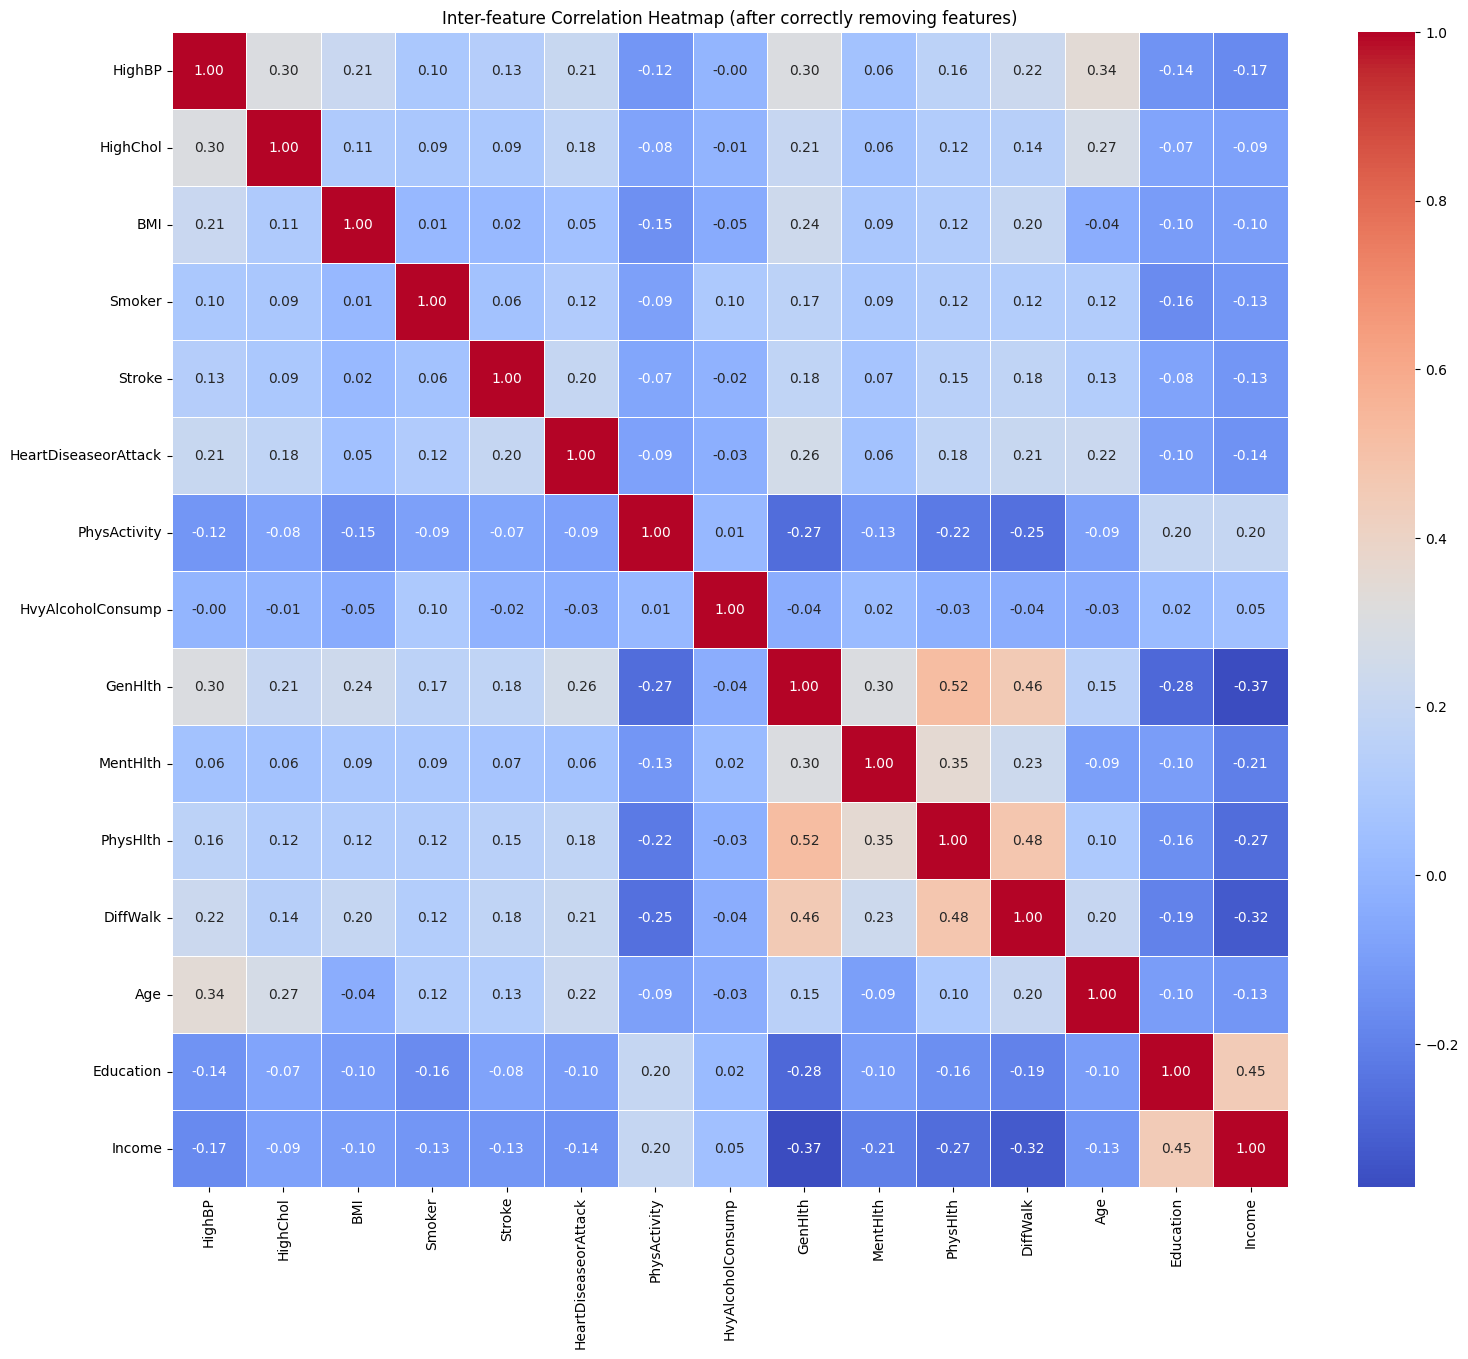


before dropping: 21
attempted to drop: ['NoDocbcCost', 'Fruits', 'Veggies', 'Sex', 'AnyHealthcare', 'CholCheck']
Features after dropping: 15
Remaining features: ['HighBP', 'HighChol', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'HvyAlcoholConsump', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Age', 'Education', 'Income']


In [ ]:

#dropping features
features_to_drop = [
    'NoDocbcCost', 'Fruits', 'Veggies', 'Sex',
    'AnyHealthcare', 'CholCheck'
]


# 'pdx' ---> original datafarme foem traiinset
# .copy() ---> araksawata use krnne, nttm main dataframe eka edit wenn pluwn!!!
# 'errors='ignore''column ekak hmbune nththm err ek ignore krnw
pdx_after_drop = pdx.drop(columns=features_to_drop, errors='ignore').copy()

pdx_after_drop_corr = pdx_after_drop.corr()

print("Corrected Inter-feature Correlation Matrix (first 5 rows/cols after dropping features):")
display(pdx_after_drop_corr.head())

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(18, 15))
sns.heatmap(pdx_after_drop_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Inter-feature Correlation Heatmap (after correctly removing features)')
plt.show()

print(f"\nbefore dropping: {pdx.shape[1]}")
print(f"attempted to drop: {features_to_drop}")
print(f"Features after dropping: {pdx_after_drop.shape[1]}")
print(f"Remaining features: {list(pdx_after_drop.columns)}")

### Separate Preprocessing for Numerical and Categorical Features

As discussed, we need to apply different preprocessing techniques to numerical and categorical features.

1.  **Numerical Features:** We will use `StandardScaler` to standardize them.
2.  **Categorical Features:** We will use `OneHotEncoder` to convert them into a binary matrix.

First, let's explicitly define which features in `pdx_after_drop` are numerical and which are categorical based on our previous understanding of the dataset.

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify numerical & categorical features ---> pdx_after_drop

# remaining in pdx_after_drop:
# ['HighBP', 'HighChol', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack',
#  'PhysActivity', 'HvyAlcoholConsump', 'GenHlth', 'MentHlth', 'PhysHlth',
#  'DiffWalk', 'Age', 'Education', 'Income']

numerical_features = [
    'BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Income'
]
categorical_features_for_ohe = [
    'HighBP', 'HighChol', 'Smoker', 'Stroke', 'HeartDiseaseorAttack',
    'PhysActivity', 'HvyAlcoholConsump', 'DiffWalk', 'Education'
]

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_for_ohe)
    ])

pdx_processed = preprocessor.fit_transform(pdx_after_drop)


# get_feature_names_out method:  returns the column names in the order they appear from the numerical and one-hot encoded features.

# The order of the feature names must match the order from preprocessor
# get numerical feature names first, next categorical feature names
feature_names = numerical_features + \
                list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features_for_ohe))

# Convert processed array --> DataFrame
pdx_final_df = pd.DataFrame(pdx_processed, columns=feature_names, index=pdx_after_drop.index)

print("Original features (first 5 rows of numerical and categorical):")
display(pdx_after_drop[numerical_features + categorical_features_for_ohe].head())

print("\nProcessed features (first 5 rows of scaled numerical and one-hot encoded categorical):")
display(pdx_final_df.head())

print(f"\nNumber of features before processing: {pdx_after_drop.shape[1]}")
print(f"Number of features after processing and one-hot encoding: {pdx_final_df.shape[1]}")

Original features (first 5 rows of numerical and categorical):


,BMI,GenHlth,MentHlth,PhysHlth,Age,Income,HighBP,HighChol,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,HvyAlcoholConsump,DiffWalk,Education
0,28.0,2.0,0.0,0.0,2.0,5.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,4.0
1,23.0,2.0,0.0,0.0,13.0,7.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,4.0
2,29.0,1.0,0.0,0.0,9.0,8.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,6.0
3,39.0,4.0,0.0,0.0,7.0,7.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
4,16.0,5.0,30.0,30.0,7.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,5.0



Processed features (first 5 rows of scaled numerical and one-hot encoded categorical):


,BMI,GenHlth,MentHlth,PhysHlth,Age,Income,HighBP_0.0,HighBP_1.0,HighChol_0.0,HighChol_1.0,...,HvyAlcoholConsump_0.0,HvyAlcoholConsump_1.0,DiffWalk_0.0,DiffWalk_1.0,Education_1.0,Education_2.0,Education_3.0,Education_4.0,Education_5.0,Education_6.0
0,-0.057282,-0.479079,-0.430031,-0.487165,-1.977081,-0.506998,1.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-0.815055,-0.479079,-0.430031,-0.487165,1.627845,0.457948,0.0,1.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.094273,-1.415079,-0.430031,-0.487165,0.316963,0.940421,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.609820,1.392923,-0.430031,-0.487165,-0.338479,0.457948,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-1.875938,2.328923,3.614406,2.950984,-0.338479,-2.436889,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0



Number of features before processing: 15
Number of features after processing and one-hot encoding: 28


### Addressing Class Imbalance: Undersampling

Now that our features are preprocessed, the next step is to handle the class imbalance in our training dataset. We previously noted that the `Diabetes_binary` target variable is imbalanced, with a significantly larger number of samples for the '0' class (no diabetes) compared to the '1' class (diabetes).

To mitigate the issues caused by this imbalance (e.g., models being biased towards the majority class and performing poorly on the minority class), we will use **undersampling**.

**RandomUnderSampler** from the `imblearn` library is a simple and effective technique that randomly removes samples from the majority class until the desired balance is achieved. This ensures that the model gets sufficient exposure to the minority class during training.

**Important Considerations:**
*   **Apply only to training data:** Undersampling, like other resampling techniques, should only be applied to the training dataset (`pdx_final_df` and `pduse`). The test set (`xtest`, `ytest`) should remain untouched to provide an unbiased evaluation of the model's performance on real-world, imbalanced data.
*   **Information loss:** A potential drawback of undersampling is that it discards data from the majority class, which might lead to some loss of information. More advanced techniques like `EditedNearestNeighbours` or `NearMiss` try to address this by selectively removing samples.

For now, we'll start with `RandomUnderSampler` to create a balanced dataset for training our models.

In [ ]:
from imblearn.under_sampling import RandomUnderSampler


# random_state for reproducibility
rus = RandomUnderSampler(random_state=42)

print(f"shape of features before undersampling: {pdx_final_df.shape}")
print(f"sahpe of target target before undersampling: {pduse.shape}")
print(f"class distribution before undersampling:\n{pduse.value_counts()}")

# Apply undersampling to the processed features and original target variable
# pdx_final_df ---> processed training features
# pduse ---> original training target labels
X_resampled, y_resampled = rus.fit_resample(pdx_final_df, pduse)

print(f"\nfeatures - after undersampling: {X_resampled.shape}")
print(f"taregt - after undersampling: {y_resampled.shape}")
print(f"class distribution after undersampling:\n{y_resampled.value_counts()}")

# Display the first few rows of the resampled features
print("\nFirst 5 rows of resampled features:")
display(X_resampled.head())

shape of features before undersampling: (202944, 28)
sahpe of target target before undersampling: (202944,)
class distribution before undersampling:
Diabetes_binary
0.0    174667
1.0     28277
Name: count, dtype: int64

features - after undersampling: (56554, 28)
taregt - after undersampling: (56554,)
class distribution after undersampling:
Diabetes_binary
0.0    28277
1.0    28277
Name: count, dtype: int64

First 5 rows of resampled features:


,BMI,GenHlth,MentHlth,PhysHlth,Age,Income,HighBP_0.0,HighBP_1.0,HighChol_0.0,HighChol_1.0,...,HvyAlcoholConsump_0.0,HvyAlcoholConsump_1.0,DiffWalk_0.0,DiffWalk_1.0,Education_1.0,Education_2.0,Education_3.0,Education_4.0,Education_5.0,Education_6.0
75362,-0.511946,-0.479079,-0.430031,-0.487165,-0.010758,0.940421,0.0,1.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
61144,0.397382,0.456922,-0.430031,-0.487165,1.300124,-0.024525,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
143246,-0.208837,0.456922,-0.430031,-0.487165,0.972404,0.940421,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5798,-0.815055,0.456922,3.614406,-0.487165,0.644683,-0.024525,1.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
95300,-0.966610,0.456922,-0.430031,-0.487165,-1.649361,-0.024525,1.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


RandomUnderSampler's mechanism: When you don't specify a sampling_strategy or set it to 'auto' (which is the default and equivalent to setting it to 1.0 for binary classification), RandomUnderSampler identifies the minority class (diabetes=1.0) and then randomly removes samples only from the majority class (no diabetes=0.0) until the number of samples in the majority class equals the number of samples in the minority class. It never touches the minority class samples.

Stratified by class count: So, yes, it is a form of stratified undersampling because it specifically operates on the 'strata' of your classes, ensuring that the final dataset has an equal (or specified ratio) number of samples for each class. It does not touch the minority class at all, and only reduces the majority class.

To summarize: The RandomUnderSampler we've used is perfectly suited for your goal of undersampling only the 'no diabetes' class to achieve a balanced dataset for training. It effectively handles the 86% / 13% imbalance by reducing the 86% 'no diabetes' class. There's no need to switch to another method for this specific requirement, as RandomUnderSampler already fulfills it.

In [ ]:
from google.colab import files

# X_resampled
features_filename = 'undersampled_features.csv'
X_resampled.to_csv(features_filename, index=False)
print(f"'{features_filename}'")
files.download(features_filename)

# y_resampled
target_filename = 'undersampled_target.csv'
y_resampled.to_csv(target_filename, index=False)
print(f"'{target_filename}'")
files.download(target_filename)

'undersampled_features.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

'undersampled_target.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Preprocessing the Test Set

To ensure our model evaluation is accurate, we must apply the same preprocessing steps to the test set (`xtest`) that we applied to the training set.

**Crucially**, we use `.transform()` instead of `.fit_transform()` on the test set. This ensures we use the means, standard deviations, and categories learned from the training data, preventing data leakage.

In [ ]:
# 1. Drop the same features from xtest
xtest_after_drop = xtest.drop(columns=features_to_drop, errors='ignore').copy()

# 2. Transform the test set using the preprocessor fitted on training data
xtest_processed = preprocessor.transform(xtest_after_drop)

# 3. Convert to DataFrame for consistency
xtest_final_df = pd.DataFrame(xtest_processed, columns=feature_names, index=xtest.index)

print(f"Original xtest shape: {xtest.shape}")
print(f"Processed xtest shape: {xtest_final_df.shape}")

print("\nFirst 5 rows of processed test features:")
display(xtest_final_df.head())

Original xtest shape: (50736, 21)
Processed xtest shape: (50736, 28)

First 5 rows of processed test features:


,BMI,GenHlth,MentHlth,PhysHlth,Age,Income,HighBP_0.0,HighBP_1.0,HighChol_0.0,HighChol_1.0,...,HvyAlcoholConsump_0.0,HvyAlcoholConsump_1.0,DiffWalk_0.0,DiffWalk_1.0,Education_1.0,Education_2.0,Education_3.0,Education_4.0,Education_5.0,Education_6.0
128677,-0.057282,0.456922,-0.430031,-0.487165,-0.993920,0.940421,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
225051,1.155156,0.456922,-0.430031,-0.487165,0.644683,-0.989470,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
27174,-0.208837,-0.479079,-0.430031,-0.487165,-0.993920,0.940421,1.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
132371,-0.966610,-0.479079,-0.430031,-0.487165,0.972404,0.457948,1.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
164896,-0.360391,1.392923,-0.430031,0.315070,1.627845,-1.954416,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


**Reasoning**:
The subtask requires converting the `ytest` Series to a DataFrame and saving it as a CSV. This code block will perform both actions and make the file available for download.



In [ ]:
import pandas as pd
from google.colab import drive
from sklearn.model_selection import train_test_split
from google.colab import files

# Ensure drive is mounted and data is loaded to define x, y, and ytest
drive.mount('/content/drive', force_remount=True)
file_path = '/content/drive/MyDrive/datasets/diabetes_binary_health_indicators_BRFSS2015.csv'

df = pd.read_csv(file_path)
x = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

# Perform train_test_split to get ytest
_, _, _, ytest = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

ytest_df = ytest.to_frame(name='Diabetes_binary')
ytest_filename = 'ytest.csv'
ytest_df.to_csv(ytest_filename, index=False)
print(f"Saved '{ytest_filename}'")
files.download(ytest_filename)

Mounted at /content/drive
Saved 'ytest.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

# Save the preprocessed test features to a CSV file
test_features_filename = 'preprocessed_xtest.csv'
xtest_final_df.to_csv(test_features_filename, index=False)
print(f"Saved '{test_features_filename}'")

# Download the file
files.download(test_features_filename)

Saved 'preprocessed_xtest.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
features_filename = 'testsplit.csv'
xtest_final_df.to_csv(features_filename, index=False)
print(f"'{features_filename}'")
files.download(features_filename)

NameError: name 'test_final_df' is not defined

# Task
Create a CSV file for `ytest` data, which is currently a pandas Series, then save it to a CSV file named `'ytest.csv'`, and finally download it.

## Prepare Ytest for Download

### Subtask:
Convert the `ytest` data (which is a pandas Series) into a DataFrame and save it to a CSV file.
